In [1]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device GPU: Tesla P100-PCIE-16GB
ℹ️ No. of CPU: 4 cores


/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 Tesla P100-PCIE-16GB which is of cuda capability 6.0.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
Tesla P100-PCIE-16GB with CUDA capability sm_60 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the Tesla P100-PCIE-16GB GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  queued_call()


In [2]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools

## -- Machine Learning --
import tensorflow as tf

import sklearn
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.calibration import CalibrationDisplay

import warnings

2026-05-06 22:08:32.511291: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778105312.704687      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778105312.768782      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778105313.252664      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778105313.252705      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778105313.252708      23 computation_placer.cc:177] computation placer alr

In [3]:
## -- Global Settings --

# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

## -- Set Global Seed --
class CFG():
    SEED   = 42
    GREEN  = '\033[32m'
    YELLOW = '\033[33m'
    RESET  = '\033[0m'

tf.keras.utils.set_random_seed(CFG.SEED)

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    "axes.edgecolor":   '#444466',
    "axes.labelcolor":  '#e0e0ff',
    "text.color":       'lightblue',
    "xtick.color":      '#e0e0ff',
    "ytick.color":      '#e0e0ff',
    "grid.color":       '#2a2a4a',
    "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', 'm', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

print(f"CLASSIC {CFG.GREEN} GREEN {CFG.RESET} {CFG.YELLOW} CFG.YELLOW {CFG.RESET}")

CLASSIC  GREEN   CFG.YELLOW 


In [4]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e5/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+"train.csv").drop(columns=['id'])
    test = pd.read_csv(PATH+"test.csv").drop(columns=['id'])
    ORIG_PATH = '/kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/'
    orig = pd.read_csv(ORIG_PATH+'f1_strategy_dataset_v4.csv')#.drop(['customerID'], axis=1)
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/--colab--notebooks--/Ps6e5 | F1 Pits Stop/_f1_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv').drop(columns=['id'])
    test = pd.read_csv(PATH+'test.csv').drop(columns=['id'])
    orig = pd.read_csv(PATH+'f1_strategy_dataset_v4.csv')#.drop(['customerID'], axis=1)

## =================================================================================

TARGET = train.columns[-1]

CATS = [c for c in test.columns if test[c].dtype in ['str', 'object', 'category']]
NUMS = [c for c in test.columns if c not in CATS+[TARGET]]
BASE = NUMS + CATS

orig = orig[train.columns]

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Nums: {len(NUMS)}")
print(f"Total Cats: {len(CATS)}")
print(f"Total Base: {len(BASE)}")

Train shape: (439140, 15)
Test shape: (188165, 14)
Original shape: (101371, 15)

Total Nums: 11
Total Cats: 3
Total Base: 14


In [5]:
display(train.head())
train.info()

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  439140 non-null  object 
 1   Compound                439140 non-null  object 
 2   Race                    439140 non-null  object 
 3   Year                    439140 non-null  int64  
 4   PitStop                 439140 non-null  int64  
 5   LapNumber               439140 non-null  int64  
 6   Stint                   439140 non-null  int64  
 7   TyreLife                439140 non-null  float64
 8   Position                439140 non-null  int64  
 9   LapTime (s)             439140 non-null  float64
 10  LapTime_Delta           439140 non-null  float64
 11  Cumulative_Degradation  439140 non-null  float64
 12  RaceProgress            439140 non-null  float64
 13  Position_Change         439140 non-null  float64
 14  PitNextLap          

In [6]:
train.describe()

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


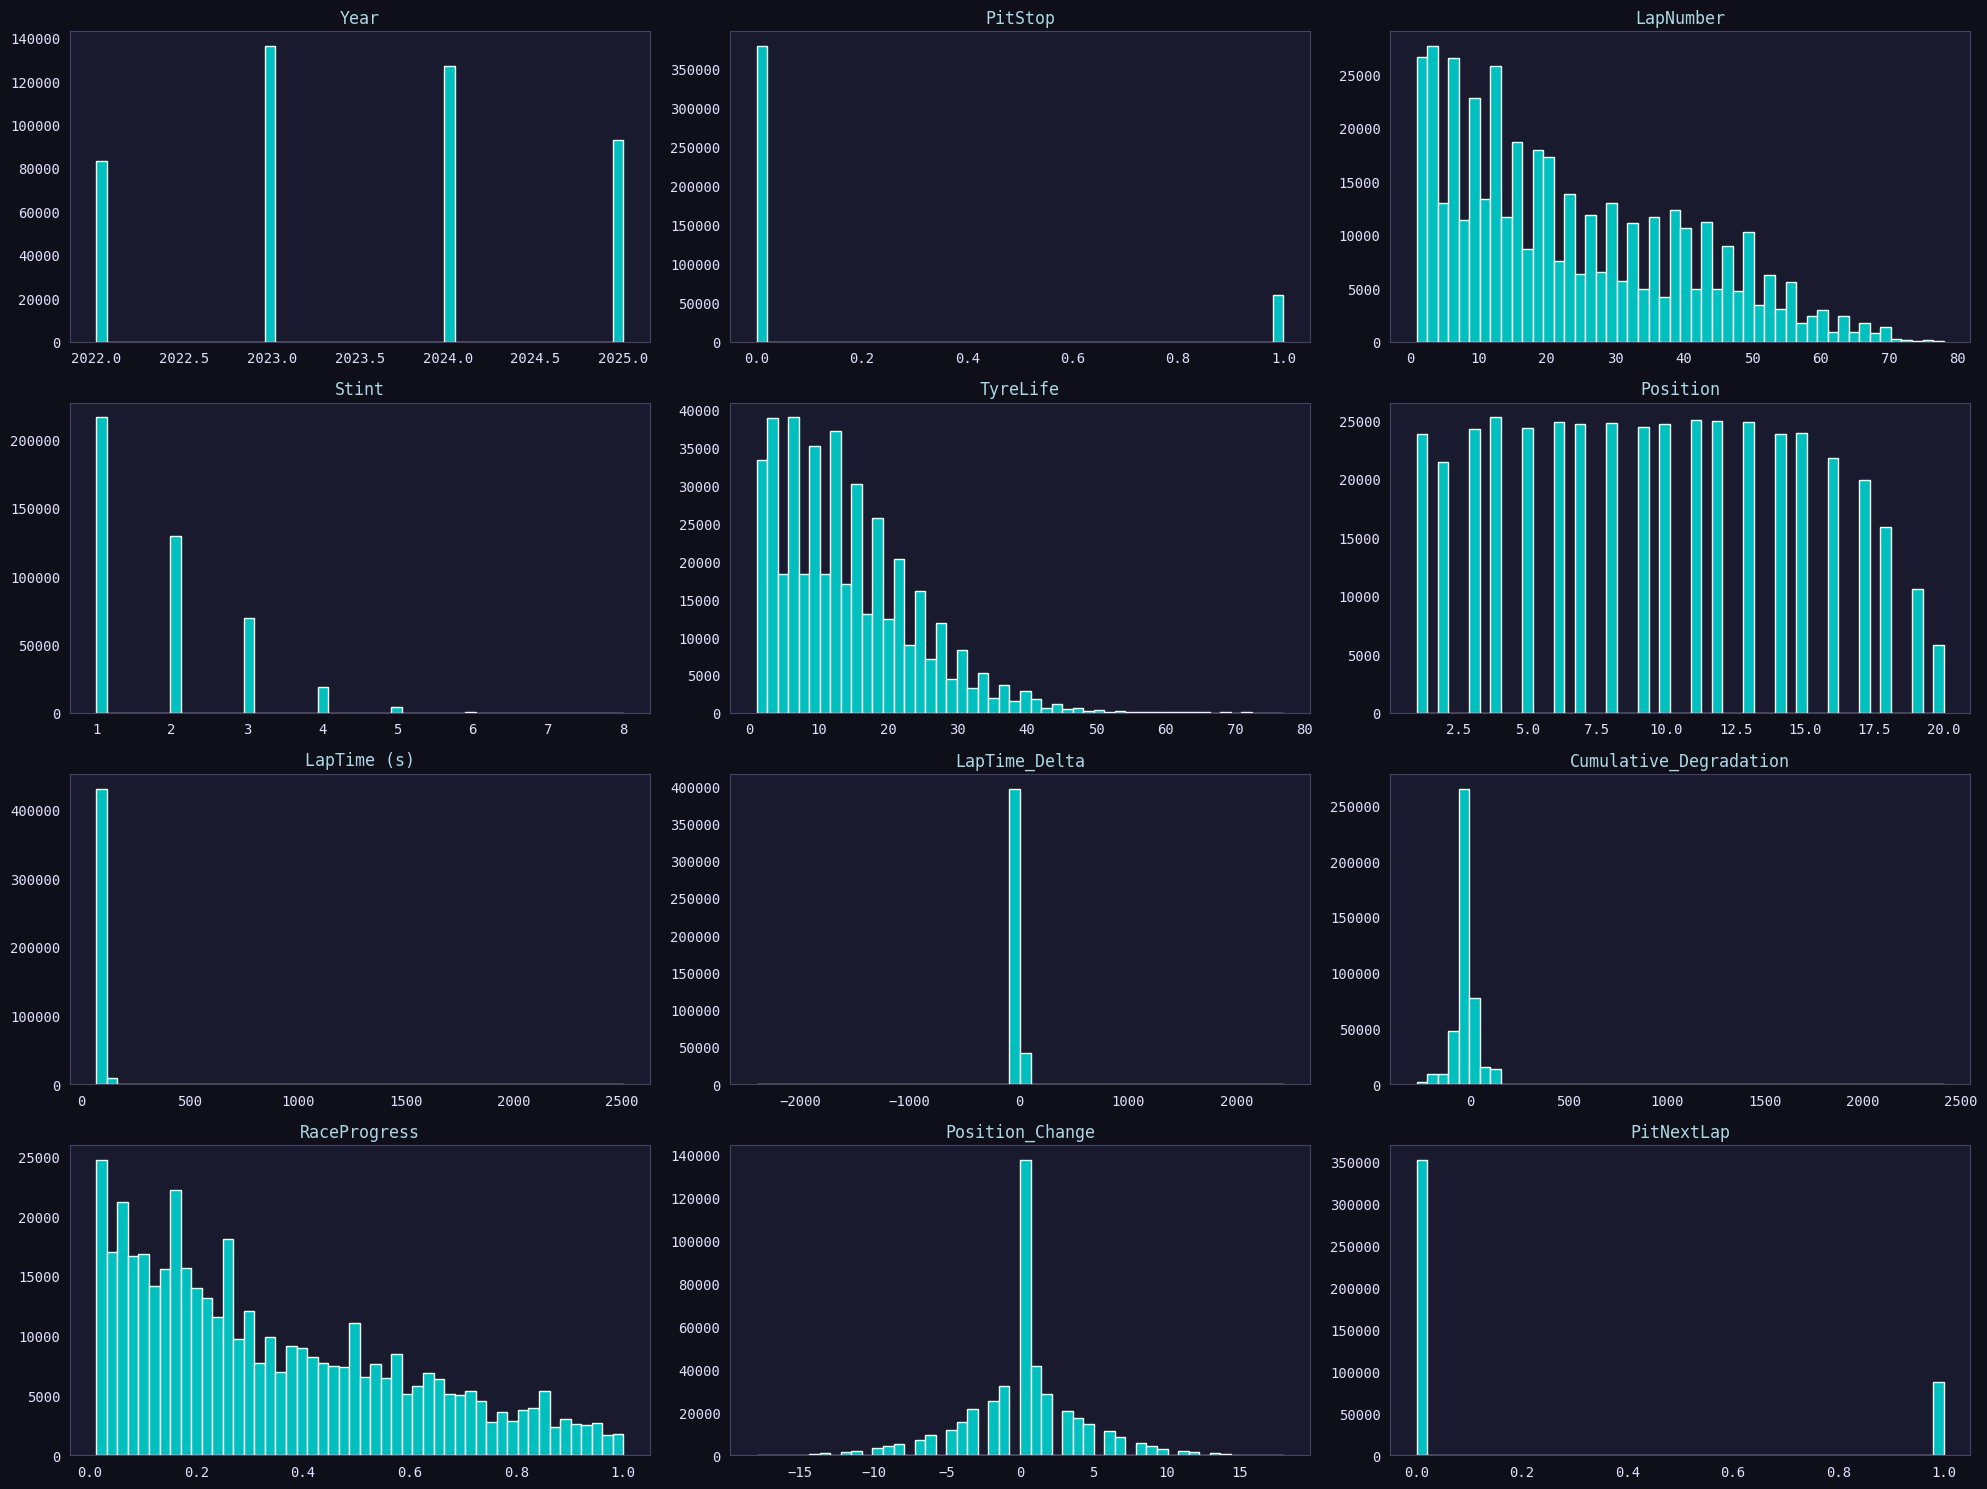

In [7]:
ax = train.hist(figsize=(20, 15), bins=50, grid=False)
plt.tight_layout()
plt.show()

In [8]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {} 
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,Driver,Compound,Race
Train,4,2,78,8,78,20,37719,57532,142701,1898,37,887,5,26
Original,4,2,78,8,78,20,40779,54084,81360,1437,37,31,5,28
Test,4,2,77,8,77,20,30286,40673,86823,1556,37,801,5,26


In [9]:
n_unique = train[BASE].nunique().sort_values()
n_unique

PitStop                        2
Year                           4
Compound                       5
Stint                          8
Position                      20
Race                          26
Position_Change               37
LapNumber                     78
TyreLife                      78
Driver                       887
RaceProgress                1898
LapTime (s)                37719
LapTime_Delta              57532
Cumulative_Degradation    142701
dtype: int64

In [10]:
## -- Optimal Binning --
try:
    import optbinning
except:
    %pip install -q -U optbinning
    import optbinning

def _opt_binning(
    x_tr, y_tr, x_vl, x_ts, bin_features, method='cart',
    solver='cp', metric='mean_woe', pre_bins=100, period=100):
    """
    metric: 'mean_woe' or 'weighted_mean_woe': floats or 'indices': integers
    """
    x_train = x_tr.copy()
    x_valid = x_vl.copy()
    x_test  = x_ts.copy()

    for c in bin_features:
        if x_train[c].dtype in ['str', 'object', 'category']:
            combine  = pd.concat([x_train[c], x_valid[c], x_test[c]])
            combine  = combine.factorize()[0]
            # combine  = pd.Series(combine).astype('category')
            x_train[c] = combine[:len(x_train)]
            x_valid[c] = combine[len(x_train):len(x_train)+len(x_valid)]
            x_test[c]  = combine[-len(x_test):]

    opt_modules_per_col = []
    opt_cols = []

    # print(f'OptimalBinning {len(bin_features)}: ', end='')
    for col in tqdm(bin_features, desc='Optimal_Binning'):
        # print(f'{col}... ', end='')
        opt_b = optbinning.OptimalBinning(
            name=col,
            dtype='numerical',
            prebinning_method=method, # d='cart', 'quantile'
            # class_weight='balanced',
            # min_prebin_size=0.02, # d=0.05
            # cat_cutoff=0.01,
            solver=solver,
            max_n_prebins=pre_bins, # d=20
            # min_n_bins=2, max_n_bins=100,
            # min_bin_size=0.1, max_bin_size=0.9,
            time_limit=period, # d=100 (secs)
            # verbose=True,
        )

        opt_b.fit(x_train[col].to_numpy(), y_tr.to_numpy())

        new_col = f'{col}_optBin'
        x_train[new_col] = opt_b.transform(x_train[col].to_numpy(), metric=metric)
        x_valid[new_col] = opt_b.transform(x_valid[col].to_numpy(), metric=metric)
        x_test[new_col]  = opt_b.transform(x_test[col].to_numpy(),  metric=metric)

        opt_cols.append(new_col)
        opt_modules_per_col.append(opt_b)

    return opt_modules_per_col, opt_cols, x_train, x_valid, x_test

print('Binning function ready')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.8/214.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 21.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
a2a-sdk 0.3.25 requires protobuf>=5.29.5, but you have protobuf 5.26.1 which is incompatible.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 5.26.1 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, b

In [11]:
opt_bins, opt_bin_cols, train2, orig2, test2 = _opt_binning(
    x_tr=train,
    y_tr=train[TARGET],
    x_vl=orig,
    x_ts=test,
    bin_features=n_unique.index[-5:],
    method='cart', # 'cart', 'quantile'
    solver='cp', # 'cp', 'mip', 'ls'
    metric='woe', # 'woe','weighted_mean_woe','indices','bins'
    pre_bins=100, 
    period=100,
)

print(f"Total bin features: {len(opt_bin_cols)}")
train2.head()

Optimal_Binning:   0%|          | 0/5 [00:00<?, ?it/s]

Total bin features: 5


,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap,Driver_optBin,RaceProgress_optBin,LapTime (s)_optBin,LapTime_Delta_optBin,Cumulative_Degradation_optBin
0,0,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0,-0.004887,-0.636536,-0.305507,-0.471509,0.414138
1,1,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0,-0.004887,-0.347403,-0.305507,-0.471509,-1.283549
2,2,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0,-0.004887,0.633917,-0.305507,-0.471509,-0.295905
3,3,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0,-0.004887,1.247513,0.373009,-0.471509,0.414138
4,4,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0,-0.004887,-0.347403,0.030017,-0.326402,0.414138


Optimal Binned Features: 5


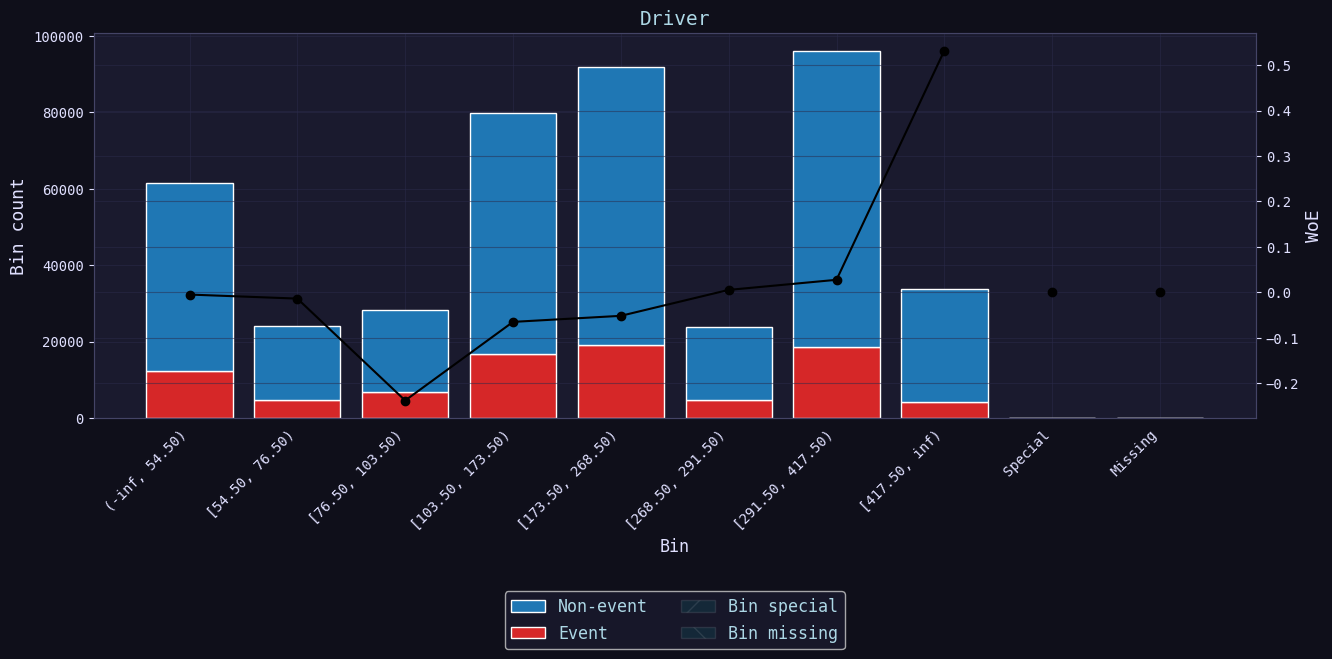

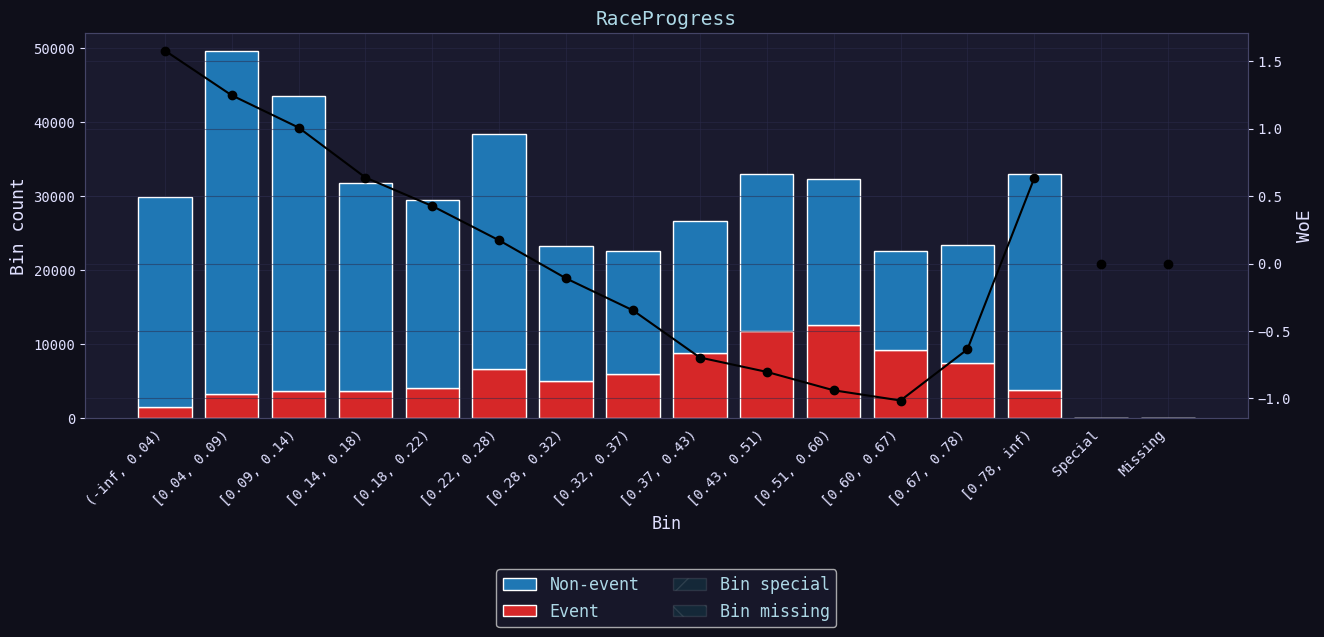

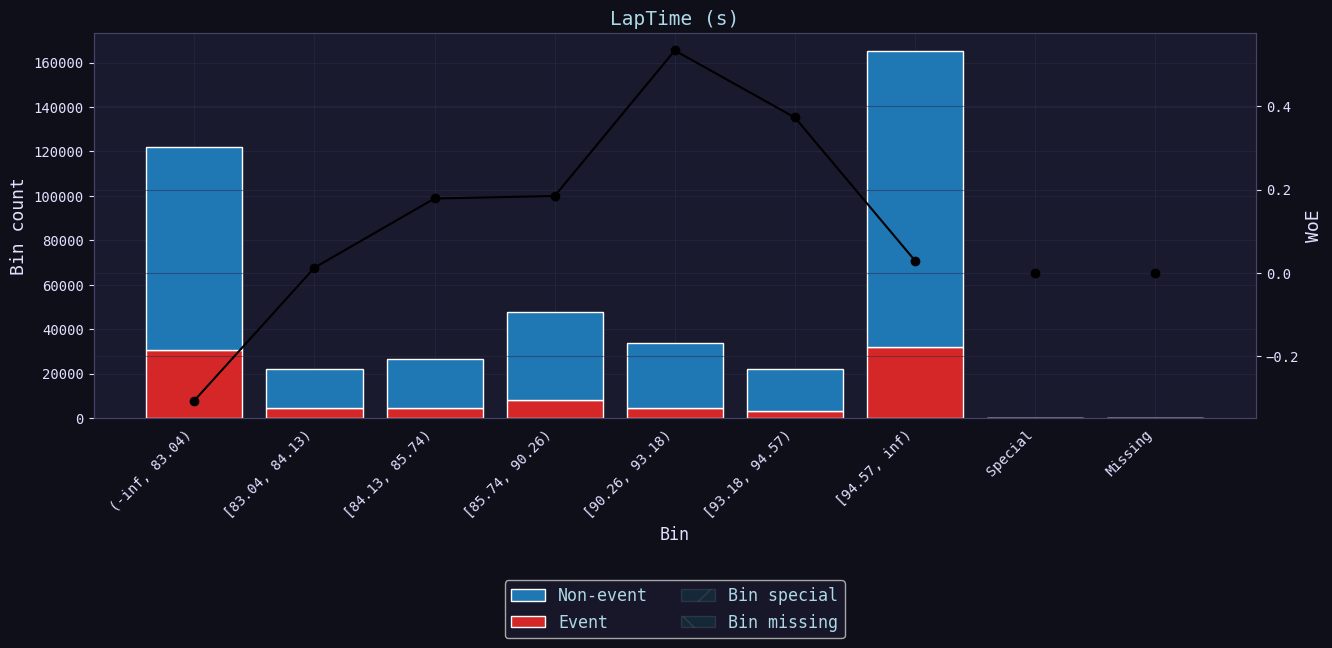

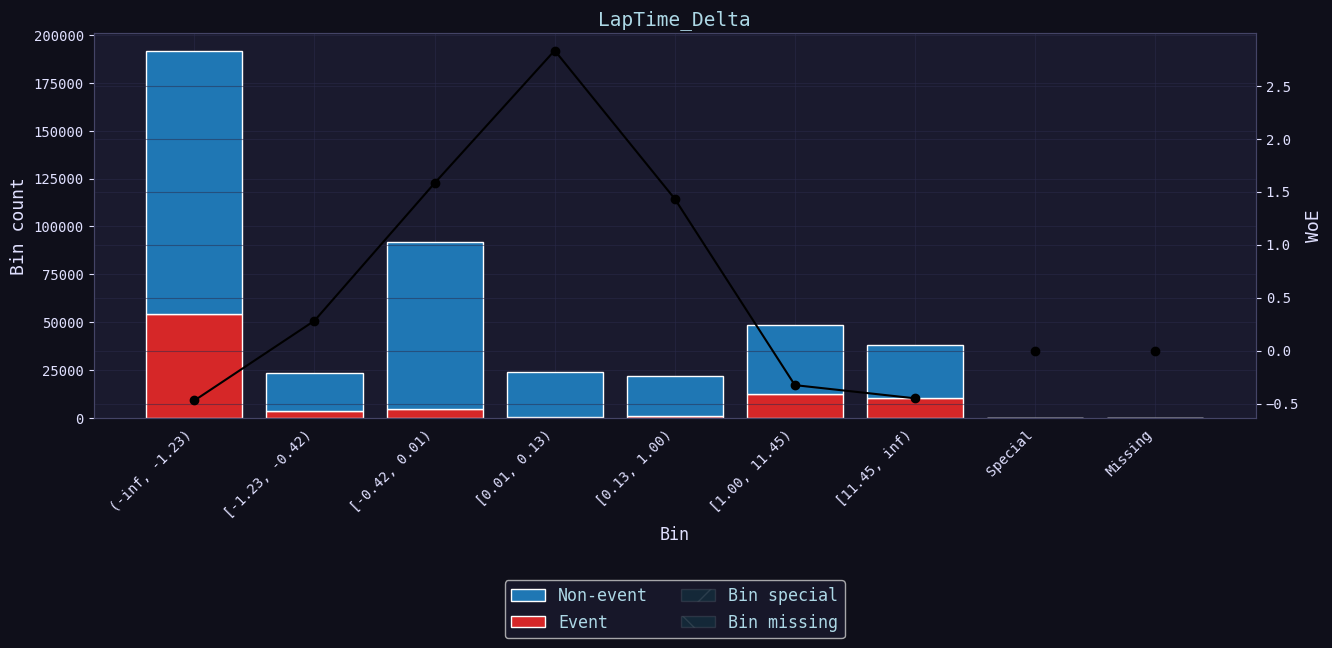

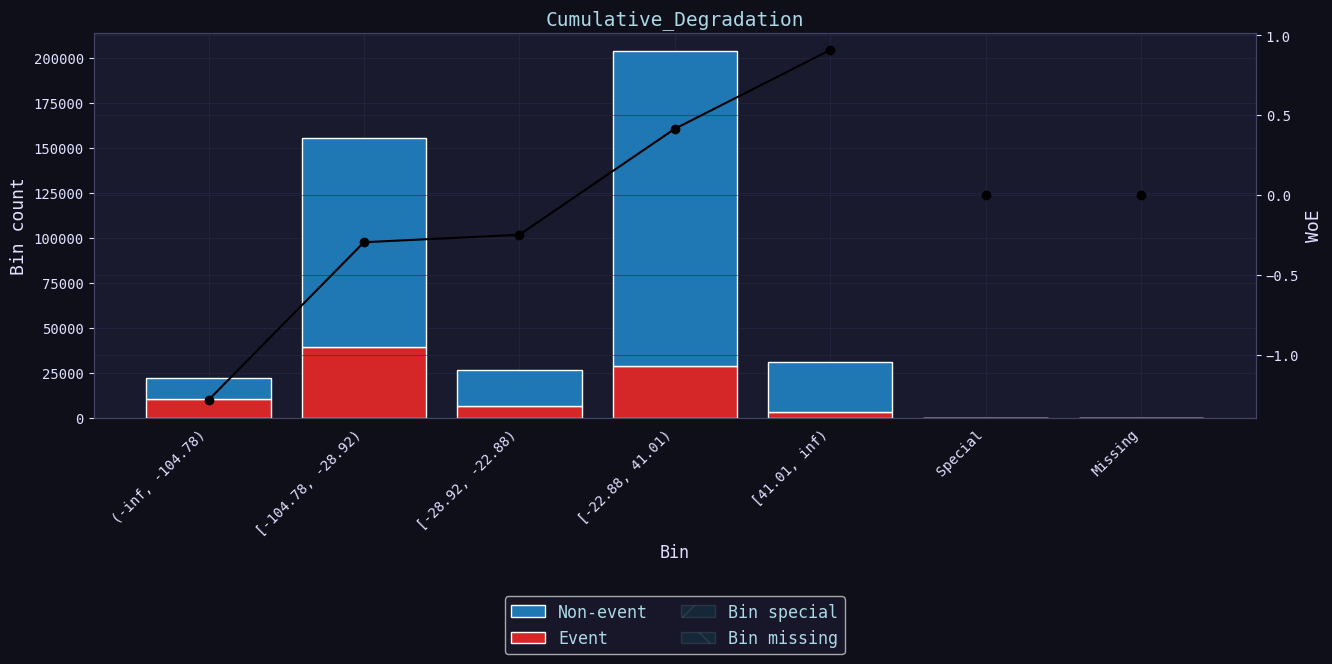

In [12]:
BIN_TABLES = []

for opt_ in opt_bins:
    # print(opt_bins[col_n].status, opt_bins[col_n].splits)
    opt_table = opt_.binning_table
    opt_table.build()
    # display(opt_table.build())
    BIN_TABLES.append(opt_table)

print('Optimal Binned Features:', len(BIN_TABLES))

## -- Plot optimal bin points --
for i, opt_ in enumerate(BIN_TABLES):
    opt_.plot(show_bin_labels=True, figsize=(15, 5))
    print()

## FEATURE ENGINEERING

In [13]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 2
digit_thresh = 2

round_thresh, digit_thresh

(2, 2)

In [14]:
_VALUES = ['Cumulative_Degradation', 'LapTime (s)'] # 'LapTime_Delta'

print(f"\nRounding... ", end='')
for col in _VALUES:
    for r in [-2, -1, 0, 1, 2]:
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')

        ## -- Drop irrelevant features --
        if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
            DROP_COLS.append(r_n)
        else:
            ROUNDS.append(r_n)

    # print(f"\nDIGITS... ", end='')
    # for d in [-3, -2, -1, 0, 1, 2, 3]:
    #     d_n = f'{col}_digit_{d}'
    #     print(d_n+', ', end='')
    #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
    #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
    #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

    #     ## -- Drop constant features --
    #     if train[d_n].nunique() < digit_thresh:
    #         DROP_COLS.append(d_n)
    #     else:
    #         DIGITS.append(d_n)

    # print(f"\nCreating value-based E_BINS... ", end='')
    # for b in [100]:
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)

    # print(f"\nCreating quantile-based Q_BINS... ", end='')
    # for q in [100]:
    #     q_n = f'{col}_Qbin_{q}'
    #     print(q_n+', ', end='')
    #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
    #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ Total ROUNDS: {len(ROUNDS)}')
print(f"✅ Total DIGITS: {len(DIGITS)}")
print(f"✅ Total E_BINS: {len(E_BINS)}")
print(f"✅ Total Q_BINS: {len(Q_BINS)}")


Rounding... Cumulative_Degradation_round_-2, Cumulative_Degradation_round_-1, Cumulative_Degradation_round_0, Cumulative_Degradation_round_1, Cumulative_Degradation_round_2, LapTime (s)_round_-2, LapTime (s)_round_-1, LapTime (s)_round_0, LapTime (s)_round_1, LapTime (s)_round_2, 
✅ Total ROUNDS: 10
✅ Total DIGITS: 0
✅ Total E_BINS: 0
✅ Total Q_BINS: 0


In [15]:
# print(f"\nRounding... ", end='')
# for col in ['LapTime (s)']:
#     for r in [-2, -1, 0, 1, 2]:
#         r_n = f"{col}_round_{r}"
#         print(r_n+', ', end='')
#         train[r_n] = train[col].round(r).astype('int32')
#         test[r_n]  = test[col].round(r).astype('int32')
#         orig[r_n]  = orig[col].round(r).astype('int32')
#         ## -- Drop irrelevant features --
#         if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#             DROP_COLS.append(r_n)
#         else:
#             ROUNDS.append(r_n)

#     # print(f"\nDIGITS... ", end='')
#     # for d in [0, 1, 2, 3, 4, 5, 6]:
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [10]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nCreating quantile-based Q_BINS... ", end='')
#     # for q in [5]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [16]:
train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

Cumulative_Degradation_round_-2      7
Cumulative_Degradation_round_-1     51
Cumulative_Degradation_round_0     454
Cumulative_Degradation_round_1     447
Cumulative_Degradation_round_2     445
LapTime (s)_round_-2                 5
LapTime (s)_round_-1                25
LapTime (s)_round_0                137
LapTime (s)_round_1                134
LapTime (s)_round_2                132
dtype: int64

In [17]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


In [18]:
train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

Cumulative_Degradation_round_-2      7
Cumulative_Degradation_round_-1     51
Cumulative_Degradation_round_0     454
Cumulative_Degradation_round_1     447
Cumulative_Degradation_round_2     445
LapTime (s)_round_-2                 5
LapTime (s)_round_-1                25
LapTime (s)_round_0                137
LapTime (s)_round_1                134
LapTime (s)_round_2                132
dtype: int64

In [19]:
def add_frequency_condition(df1, cols, thresh=5): 
    df = df1.copy()
    for c in cols:
        v_counts = df[c].value_counts()
        to_replace = v_counts[v_counts <= thresh].index
        df[c] = np.where(df[c].isin(to_replace), -1, df[c])

    return df

train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

print(f"Frequency threshold imputed!")

Frequency threshold imputed!


In [20]:
# ## -- Arithmetic interaction --
# for df in [train, test, orig]:
#     df['_MonthlyCharges_/_TotalCharges'] = (df['MonthlyCharges'] / (df['TotalCharges'] + 1e-6)).astype('float32')
#     df['_TotalCharges_/_tenure']  = (df['TotalCharges'] / (df['tenure'] + 1e-6)).astype('float32')
#     df['_Monthly_to_avg_ratio'] = (df['MonthlyCharges'] / (df['_TotalCharges_/_tenure'] + 1e-6)).astype('float32')
#     df['_TotalCharges_/_MonthlyCharges']  = (df['TotalCharges'] / (df['MonthlyCharges'] + 1e-6)).astype('float32')
#     df['_tenure_sq'] = (df['tenure'] ** 2).astype("float32")

# arithmetic = ['_MonthlyCharges_/_TotalCharges', '_TotalCharges_/_tenure',
#               '_Monthly_to_avg_ratio', '_TotalCharges_/_MonthlyCharges', '_tenure_sq']

# train[arithmetic].head()

In [21]:
# ## -- Cyclic encoding --
# for df in [train, test, orig]:
#     for p in [12, 30]:
#         df[f"MonthlyCharges_sin_{p}"] = np.sin(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')
#         df[f"MonthlyCharges_cos_{p}"] = np.cos(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')

In [22]:
## -- Frequency encoding --
freq_cols = []

print(f"\nCreating frequencies... ", end='')
for col in n_unique.index[4:]:
    freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
    n = f'{col}_freq'
    print(n+', ', end='')
    for df in [train, test, orig]:
        df[n] = df[col].map(freq).fillna(0).astype('float32')
    freq_cols.append(n)

print(f"\n✓ Total frequency features: {len(freq_cols)}")


Creating frequencies... Position_freq, Race_freq, Position_Change_freq, LapNumber_freq, TyreLife_freq, Driver_freq, RaceProgress_freq, LapTime (s)_freq, LapTime_Delta_freq, Cumulative_Degradation_freq, 
✓ Total frequency features: 10


In [23]:
INTER = []
top_cols = ['PitStop', 'Year', 'Compound', 'Stint', 'Race'] 
low_cols = ['Position', 'Position_Change', 'LapNumber', 'Driver']

for c1, c2 in tqdm(list(itertools.combinations(top_cols, 2)), desc='Pairwise'):
    n_col = f"Bi_{c1}-|-{c2}"
    train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
    test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
    orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
    INTER.append(n_col)

# for c1, c2, c3 in tqdm(list(itertools.combinations(top_cols, 3)), desc='Triplewise'):
#     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
#     INTER.append(n_col)

# for c1, c2 in tqdm(list(itertools.product(top_cols, low_cols)), desc='One-to-Many'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

print(f"Total Interaction Features: {len(INTER)}")

Pairwise:   0%|          | 0/10 [00:00<?, ?it/s]

Total Interaction Features: 10


In [24]:
sleep(2); gc.collect()

35794

In [25]:
# ## -- Reduce data memory --
# def reduce_memory(df):
#     old_size = sys.getsizeof(df) / (1024*1024)
#     for c in tqdm(df.columns, desc='Reducing memory...'):
#         ## -- Downcast Integer type ---
#         if df[c].dtype == np.int64: 
#             if df[c].min() > np.iinfo(np.int32).min and df[c].max() < np.iinfo(np.int32).max:
#                 df[c] = df[c].astype(np.int32)
#                 # if df[c].min() > np.iinfo(np.int16).min and df[c].max() < np.iinfo(np.int16).max:
#                 #     df[c] = df[c].astype(np.int16)
#                 #     if df[c].min() > np.iinfo(np.int8).min and df[c].max() < np.iinfo(np.int8).max:
#                 #         df[c] = df[c].astype(np.int8)
#         ## -- Downcast Float type -----
#         # elif df[c].dtype == np.float64:
#         #     if df[c].min() > np.finfo(np.float32).min and df[c].max() < np.finfo(np.float32).max:
#         #         df[c] = df[c].astype(np.float32)
#                 # if df[c].min() > np.finfo(np.float16).min and df[c].max() < np.finfo(np.float16).max:
#                 #     df[c] = df[c].astype(np.float16)

#     new_size = sys.getsizeof(df) / (1024*1024)
#     print(f"Size before process: {old_size:.1f}MB")
#     print(f"Size after process : {new_size:.1f}MB\n")
    
#     return df

# train = reduce_memory(train)
# test = reduce_memory(test)
# orig = reduce_memory(orig)

# gc.collect()

# print(f"Data memory reduced!")

In [26]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [27]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()
    
    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [28]:
# train, test, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE+DIGITS,
#     target=TARGET,
#     aggs=['mean', 'std'], # mean, median, count, std, skew, nunique, max, min
#     # fill_nan=True,
# )

# print(F"ORIGINAL FEATURES MERGED: {len(ORIG_COLS)}")

In [29]:
# ## -- Duplicate all numerics as categories --
# CATS_2 = []

# for c in NUMS:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     orig[n]  = orig[c].copy()
#     CATS_2.append(n)

#     ## -- FACTORIZE CATS_2 --
#     combine  = pd.concat([train[n], test[n], orig[n]])
#     v = combine.factorize()[0]
#     train[n] = v[:len(train)].astype('int32')
#     test[n]  = v[len(train):len(train)+len(test)].astype('int32')
#     orig[n]  = v[len(train)+len(test):].astype('int32')

# print(f'Numericals to Categoricals: {len(CATS_2)}')

In [30]:
## -- Factorize using combined data --
for c in CATS:
    combine  = pd.concat([train[c], test[c], orig[c]])
    combine  = combine.factorize()[0]
    # combine  = pd.Series(combine).astype('category')
    train[c] = combine[:len(train)]
    test[c]  = combine[len(train):len(train)+len(test)]
    orig[c]  = combine[-len(orig):]

print('Label encoding complete!')

Label encoding complete!


In [31]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train[FEATURES].head(3)

Total Features: 44


,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,Cumulative_Degradation_round_-2,Cumulative_Degradation_round_-1,Cumulative_Degradation_round_0,Cumulative_Degradation_round_1,Cumulative_Degradation_round_2,LapTime (s)_round_-2,LapTime (s)_round_-1,LapTime (s)_round_0,LapTime (s)_round_1,LapTime (s)_round_2,Position_freq,Race_freq,Position_Change_freq,LapNumber_freq,TyreLife_freq,Driver_freq,RaceProgress_freq,LapTime (s)_freq,LapTime_Delta_freq,Cumulative_Degradation_freq,Bi_PitStop-|-Year,Bi_PitStop-|-Compound,Bi_PitStop-|-Stint,Bi_PitStop-|-Race,Bi_Year-|-Compound,Bi_Year-|-Stint,Bi_Year-|-Race,Bi_Compound-|-Stint,Bi_Compound-|-Race,Bi_Stint-|-Race
0,0,0,0,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,0,20,21,21,21,100,80,78,78,78,0.056218,0.048945,0.032379,0.011480,0.00349,0.002034,0.000915,0.000107,0.000056,0.000003,0_2022,0_HARD,0_2,0_Canadian Grand Prix,2022_HARD,2022_2,2022_Canadian Grand Prix,HARD_2,HARD_Canadian Grand Prix,2_Canadian Grand Prix
1,1,0,1,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,-200,-220,-223,-223,-223,100,80,75,75,75,0.057272,0.055289,0.049089,0.012781,0.04217,0.002207,0.002768,0.000115,0.000007,0.000001,1_2025,1_HARD,1_2,1_Dutch Grand Prix,2025_HARD,2025_2,2025_Dutch Grand Prix,HARD_2,HARD_Dutch Grand Prix,2_Dutch Grand Prix
2,2,0,2,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,-100,-100,-101,-100,-100,100,70,71,70,70,0.056309,0.047861,0.047057,0.003255,0.02284,0.002893,0.001118,0.000041,0.000059,0.000007,0_2022,0_HARD,0_3,0_Austrian Grand Prix,2022_HARD,2022_3,2022_Austrian Grand Prix,HARD_3,HARD_Austrian Grand Prix,3_Austrian Grand Prix


# ML TRAINING

In [32]:
## -- Check for 3rd party libraries (tpu) --
try:
    import xgboost as xgb
except:
    %pip install -q xgboost
    import xgboost as xgb

In [33]:
def Trainer_CV(model_name, params, train_df, test_df, features, target, kf, cats):
    print(f"\n==================== Starting Cross-Validation for {model_name} ====================")

    start = time()

    oof_preds = np.zeros(len(train_df))
    test_preds = np.zeros(len(test_df))
    fold_scores = []

    for idx, (train_idx, val_idx) in enumerate(kf.split(train_df[features], train_df[target])):
        print(f"\n***** FOLD {idx + 1}/{kf.n_splits} | ", end='')

        ## -- Split data for the current fold
        X_train, X_val = train_df.loc[train_idx, features], train_df.loc[val_idx, features]
        y_train, y_val = train_df.loc[train_idx, target], train_df.loc[val_idx, target]

        X_test = test_df[features].copy()

        # ## -- OPTION A: Concatenate original data --
        # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
        # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        # ## -- OPTION B: TE Merge original data --
        # X_train, X_val, X_test, ORIG_COLS = orig_TE_data_propagate(
        #     orig,
        #     X_train,
        #     X_val,
        #     X_test,
        #     features=BASE,
        #     target=TARGET,
        #     aggs=['mean', 'std'], # mean, median, count, std, skew, nunique, max, min
        #     # fill_nan=True,
        # )

        # cme_features = ROUNDS
        # cme_cols = []

        # print(f"CategoryMeanEncoding: {len(cme_features)} | ", end='')
        # for c in cme_features:
        #     # n = f"CME_{c}"
        #     cme = CategoryMeanTransformer(cat_cols=[c])
        #     X_train[c] = cme.fit_transform(X_train[[c]], y_train).fillna(-1)
        #     X_val[c]   = cme.transform(X_val[[c]]).fillna(-1)
        #     X_test[c]  = cme.transform(X_test[[c]]).fillna(-1)
        #     cme_cols.append(c)

        # ## -- TE Opt1. -> Using CUSTOM --
        # TE_1 = TargetEncoder(NUMS, cv=5, smooth='auto', aggs=['mean'], drop_original=False)
        # X_train = TE_1.fit_transform(X_train, y_train)
        # X_val   = TE_1.transform(X_val)
        # X_test  = TE_1.transform(X_test)

        TE_1 = TargetEncoder(INTER, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        X_train = TE_1.fit_transform(X_train, y_train)
        X_val   = TE_1.transform(X_val)
        X_test  = TE_1.transform(X_test)

        combined = pd.concat([X_train, X_val, X_test])
        for c in cats:
            combined[c] = combined[c].astype(str).astype('category')
        X_train = combined.iloc[:len(X_train)]
        X_val   = combined.iloc[len(X_train):len(X_train)+len(X_val)]
        X_test  = combined.iloc[len(X_train)+len(X_val):]

        print(f"Train shape: {X_train.shape} *****")

        dtrain = xgb.DMatrix(X_train, y_train, enable_categorical=True)
        dval   = xgb.DMatrix(X_val, y_val, enable_categorical=True)
        dtest  = xgb.DMatrix(X_test, enable_categorical=True)

        model = xgb.train( 
            params,
            dtrain,
            num_boost_round=15_000,
            evals=[(dtrain, "train"), (dval, "valid")],
            early_stopping_rounds=250,
            verbose_eval=500,
        )

        ## -- Predictions --
        oof_preds[val_idx] = model.predict(dval, iteration_range=(0, model.best_iteration+1)).ravel()
        test_preds += model.predict(dtest, iteration_range=(0, model.best_iteration+1)).ravel()

        ## -- Calculate fold score --
        fold_score = roc_auc_score(y_val, oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f'{CFG.YELLOW} • Fold {idx+1} Score: {fold_score:.5f}{CFG.RESET}')

        ## -- Clean up memory --
        del X_train, y_train, y_val, X_test, dtrain, dval, dtest
        gc.collect()

    ## -- Average the test predictions --
    test_preds /= kf.n_splits

    ## -- CV results --
    print("\n==================================================")
    print(f"Cross-Validation Results for {model_name}")
    print("==================================================")
    for i, score in enumerate(fold_scores):
        print(f" • Fold {i+1} Score: {score:.5f}")

    ## -- Calculate out-of-fold Score --
    final_score = np.round(roc_auc_score(train_df[target], oof_preds), 5)

    print("-------------------------------------------------|")
    print(f"Overall Score: {final_score}")
    print(f"Average Score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print("-------------------------------------------------|")
    print(f'{((time() - start) / 60):.2f} mins\n')

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': final_score,
        'model': model,
        'val_data': X_val,
    }

print('⚙️⚙️ Training function ready ⚙️⚙️')

⚙️⚙️ Training function ready ⚙️⚙️


In [34]:
version_name = 'xgb_v0_'

all_model_predictions = {}

SEED_2 = 777
SEED_3 = 1234
SEED_4 = 24611
SEED_5 = 0

N_SPLITS = 5
kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=CFG.SEED)

kf

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [35]:
# ## ==== PARAMETER ADJUSTMENT TRAINER ====
# """
# 1. This is a trial parameter code that iterates over the defined parameters
# (learning_rate, l2, etc.) to select the best values.
# 2. It can also be used to train multiple models of the same architecture.
# 3. Comment out to proceed with actual training
# """

# if all_model_predictions:
#     all_model_predictions.clear()

# M_NAME = '_'
# COMPILER = []

# OUT_LOOP = [0]
# INN_LOOP = [0]
# p_name   = ['l1', 'l2']

# for i, outer in enumerate(OUT_LOOP):
#     for j, inner in enumerate(INN_LOOP):
#         print(f" >>> {p_name[0]} {i+1}/{len(OUT_LOOP)} -with- {p_name[1]} {j+1}/{len(INN_LOOP)} <<<")
#         PARAMS = {
#             'sampling_method': 'gradient_based',
#             # # ----------------------------------
#             # 'grow_policy': 'lossguide',
#             # 'max_leaves': 64,
#             'max_depth': 6,
#             # ------------------------------------
#             'objective': 'binary:logistic',
#             'eval_metric': 'auc',
#             'learning_rate': 0.1, #0.01
#             'subsample': 0.6,
#             'colsample_bytree': 0.2,
#             'reg_alpha': 5.0,
#             'reg_lambda': 2.0,
#             'min_child_weight': 1,
#             'random_state': CFG.SEED,
#             'verbosity': 0,
#             'n_jobs': os.cpu_count(),
#             'device': 'cuda' if torch.cuda.is_available() else 'cpu',
#         }
    
#         n = M_NAME + f"{p_name[0]}={OUT_LOOP[i]}__{p_name[1]}={INN_LOOP[j]}"
#         all_model_predictions[n] = Trainer_CV(
#             model_name=n,
#             params=PARAMS,
#             train_df=train,
#             test_df=test,
#             features=FEATURES,
#             target=TARGET,
#             kf=kf,
#             cats=['PitStop', 'Year', 'Compound', 'Stint', 'Race'],
#         )

#         COMPILER.append(all_model_predictions)

# print(f"\n====== Results ready for {len(COMPILER)} model(s) ======\n")

In [36]:
# ==================================================
# GBDT Results for _l1=6.0__l2=1.0
# ==================================================
#  • Fold 1 Score: 0.95160
#  • Fold 2 Score: 0.94908
#  • Fold 3 Score: 0.95047
#  • Fold 4 Score: 0.94979
#  • Fold 5 Score: 0.95067
# -------------------------------------------------|
# Overall Score: 0.95032
# Average Score: 0.95032 ± 0.00085
# -------------------------------------------------|
# 1.56 mins

# ==================================================
# LOSS Results for _l1=5.0__l2=3.0
# ==================================================
#  • Fold 1 Score: 0.95188
#  • Fold 2 Score: 0.94924
#  • Fold 3 Score: 0.95067
#  • Fold 4 Score: 0.94989
#  • Fold 5 Score: 0.95088
# -------------------------------------------------|
# Overall Score: 0.95051
# Average Score: 0.95051 ± 0.00090
# -------------------------------------------------|
# 3.59 mins

# ==================================================
# GRAD Results for _l1=5.0__l2=2.0
# ==================================================
#  • Fold 1 Score: 0.95166
#  • Fold 2 Score: 0.94907
#  • Fold 3 Score: 0.95063
#  • Fold 4 Score: 0.94987
#  • Fold 5 Score: 0.95081
# -------------------------------------------------|
# Overall Score: 0.95041
# Average Score: 0.95041 ± 0.00088
# -------------------------------------------------|
# 1.98 mins

In [37]:
# ## -- Get Scores --
# all_model_scores = {}
# all_scores = []

# for k, v in all_model_predictions.items():
#     for x, y in v.items():
#         if x == 'score':
#             all_model_scores[k] = y
#             all_scores.append(float(y))

# plt.figure(figsize=(16, 5))
# ax1 = sns.lineplot(all_model_scores, marker='o')
# ax1.set_title('Model Scores', fontweight='semibold')
# ax1.tick_params('x', rotation=30)

# for i, s in enumerate(all_model_scores.values()):
#     ax1.text(float(i), s+3e-6, s, ha='center')

# plt.show()

In [38]:
## ======= BOOSTING =========
M_NAME = f"{version_name}gbt_"
LR = 0.01
PARAMS = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'max_depth': 8,
    'learning_rate': LR,
    'subsample': 0.95,
    'colsample_bytree': 0.4,
    'reg_alpha': 6.0,
    'reg_lambda': 1.0,
    'min_child_weight': 4,
    'random_state': CFG.SEED,
    'verbosity': 0,
    'n_jobs': os.cpu_count(),
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

# n = M_NAME
# all_model_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=PARAMS,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=['PitStop', 'Year', 'Compound', 'Stint', 'Race'],
# )

MULTI_SEEDS = [CFG.SEED, SEED_2, SEED_3, SEED_4, SEED_5]

for value_ in MULTI_SEEDS:
    PARAMS['random_state'] = value_
    n = M_NAME + str(value_)
    all_model_predictions[n] = Trainer_CV(
        model_name=n,
        params=PARAMS,
        train_df=train,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kf=kf,
        cats=['PitStop', 'Year', 'Compound', 'Stint', 'Race'],
    )


==================== Starting Cross-Validation for xgb_v0_gbt_42 ====================

***** FOLD 1/5 | Train shape: (351312, 44) *****
[0]	train-auc:0.91999	valid-auc:0.92014
[500]	train-auc:0.94753	valid-auc:0.94474
[1000]	train-auc:0.95409	valid-auc:0.94853
[1500]	train-auc:0.95865	valid-auc:0.95026
[2000]	train-auc:0.96206	valid-auc:0.95113
[2500]	train-auc:0.96504	valid-auc:0.95169
[3000]	train-auc:0.96774	valid-auc:0.95206
[3500]	train-auc:0.97022	valid-auc:0.95231
[4000]	train-auc:0.97251	valid-auc:0.95244
[4500]	train-auc:0.97459	valid-auc:0.95254
[5000]	train-auc:0.97654	valid-auc:0.95260
[5500]	train-auc:0.97830	valid-auc:0.95261
[5956]	train-auc:0.97987	valid-auc:0.95261
 • Fold 1 Score: 0.95263

***** FOLD 2/5 | Train shape: (351312, 44) *****
[0]	train-auc:0.92069	valid-auc:0.91646
[500]	train-auc:0.94801	valid-auc:0.94242
[1000]	train-auc:0.95452	valid-auc:0.94622
[1500]	train-auc:0.95905	valid-auc:0.94792
[2000]	train-auc:0.96249	valid-auc:0.94875
[2500]	train-auc:0.965

In [39]:
## ======= LOSS GUIDE =========
M_NAME = f"{version_name}loss_"

PARAMS = {
    # ----------------------------------
    'grow_policy': 'lossguide',
    'max_leaves': 64,
    'max_depth': 0,
    # ----------------------------------
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'learning_rate': LR,
    'subsample': 0.8,
    'colsample_bytree': 0.2,
    'reg_alpha': 5.0,
    'reg_lambda': 3.0,
    'min_child_weight': 1,
    'random_state': CFG.SEED,
    'verbosity': 0,
    'n_jobs': os.cpu_count(),
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

# n = M_NAME
# all_model_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=PARAMS,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=['PitStop', 'Year', 'Compound', 'Stint', 'Race'],
# )

for value_ in MULTI_SEEDS:
    PARAMS['random_state'] = value_
    n = M_NAME + str(value_)
    all_model_predictions[n] = Trainer_CV(
        model_name=n,
        params=PARAMS,
        train_df=train,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kf=kf,
        cats=['PitStop', 'Year', 'Compound', 'Stint', 'Race'],
    )


==================== Starting Cross-Validation for xgb_v0_loss_42 ====================

***** FOLD 1/5 | Train shape: (351312, 44) *****
[0]	train-auc:0.85880	valid-auc:0.86015
[500]	train-auc:0.94221	valid-auc:0.94168
[1000]	train-auc:0.94910	valid-auc:0.94696
[1500]	train-auc:0.95274	valid-auc:0.94906
[2000]	train-auc:0.95529	valid-auc:0.95013
[2500]	train-auc:0.95737	valid-auc:0.95082
[3000]	train-auc:0.95914	valid-auc:0.95128
[3500]	train-auc:0.96073	valid-auc:0.95158
[4000]	train-auc:0.96218	valid-auc:0.95183
[4500]	train-auc:0.96355	valid-auc:0.95202
[5000]	train-auc:0.96479	valid-auc:0.95218
[5500]	train-auc:0.96599	valid-auc:0.95229
[6000]	train-auc:0.96713	valid-auc:0.95238
[6500]	train-auc:0.96820	valid-auc:0.95246
[7000]	train-auc:0.96924	valid-auc:0.95252
[7500]	train-auc:0.97023	valid-auc:0.95258
[8000]	train-auc:0.97118	valid-auc:0.95262
[8500]	train-auc:0.97210	valid-auc:0.95264
[8602]	train-auc:0.97228	valid-auc:0.95264
 • Fold 1 Score: 0.95264

***** FOLD 2/5 | Train 

In [40]:
## ======= GRADIENT-BASED =========
M_NAME = f"{version_name}grad_"

PARAMS = {
    'sampling_method': 'gradient_based',
    # ------------------------------------
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'max_depth': 6,
    'learning_rate': LR,
    'subsample': 0.6,
    'colsample_bytree': 0.2,
    'reg_alpha': 5.0,
    'reg_lambda': 2.0,
    'min_child_weight': 1,
    'random_state': CFG.SEED,
    'verbosity': 0,
    'n_jobs': os.cpu_count(),
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

# n = M_NAME
# all_model_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=PARAMS,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=['PitStop', 'Year', 'Compound', 'Stint', 'Race'],
# )

for value_ in MULTI_SEEDS:
    PARAMS['max_depth'] = value_
    n = M_NAME + str(value_)
    all_model_predictions[n] = Trainer_CV(
        model_name=n,
        params=PARAMS,
        train_df=train,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kf=kf,
        cats=['PitStop', 'Year', 'Compound', 'Stint', 'Race'],
    )


==================== Starting Cross-Validation for xgb_v0_grad_42 ====================

***** FOLD 1/5 | Train shape: (351312, 44) *****
[0]	train-auc:0.88919	valid-auc:0.88095
[500]	train-auc:0.97006	valid-auc:0.94789
[1000]	train-auc:0.98503	valid-auc:0.95114
[1500]	train-auc:0.99212	valid-auc:0.95191
[2000]	train-auc:0.99556	valid-auc:0.95213
[2500]	train-auc:0.99742	valid-auc:0.95216
[2528]	train-auc:0.99749	valid-auc:0.95217
 • Fold 1 Score: 0.95217

***** FOLD 2/5 | Train shape: (351312, 44) *****
[0]	train-auc:0.89074	valid-auc:0.87787
[500]	train-auc:0.97040	valid-auc:0.94545
[1000]	train-auc:0.98522	valid-auc:0.94879
[1500]	train-auc:0.99220	valid-auc:0.94948
[2000]	train-auc:0.99559	valid-auc:0.94962
[2400]	train-auc:0.99714	valid-auc:0.94963
 • Fold 2 Score: 0.94964

***** FOLD 3/5 | Train shape: (351312, 44) *****
[0]	train-auc:0.89008	valid-auc:0.87956
[500]	train-auc:0.97023	valid-auc:0.94663
[1000]	train-auc:0.98516	valid-auc:0.94987
[1500]	train-auc:0.99217	valid-auc:0

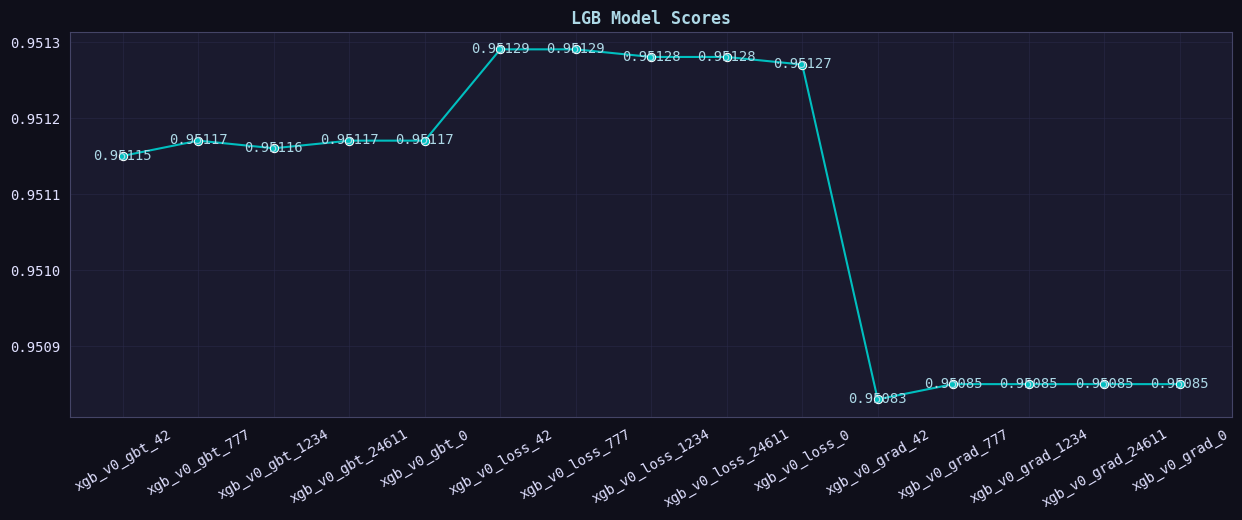

In [41]:
## -- Get Scores --
all_model_scores = {}
all_scores = []

for k, v in all_model_predictions.items():
    for x, y in v.items():
        if x == 'score':
            all_model_scores[k] = y
            all_scores.append(float(y))

plt.figure(figsize=(15, 5))
sns.lineplot(all_model_scores, marker='o')
plt.title('LGB Model Scores', fontweight='semibold')
plt.tick_params('x', rotation=30)

for i, s in enumerate(all_model_scores.values()):
    plt.text(float(i), s+3e-6, s, ha='center', va='center_baseline')

# plt.tight_layout()
plt.show()

xgb_v0_gbt_42_95115 saved!


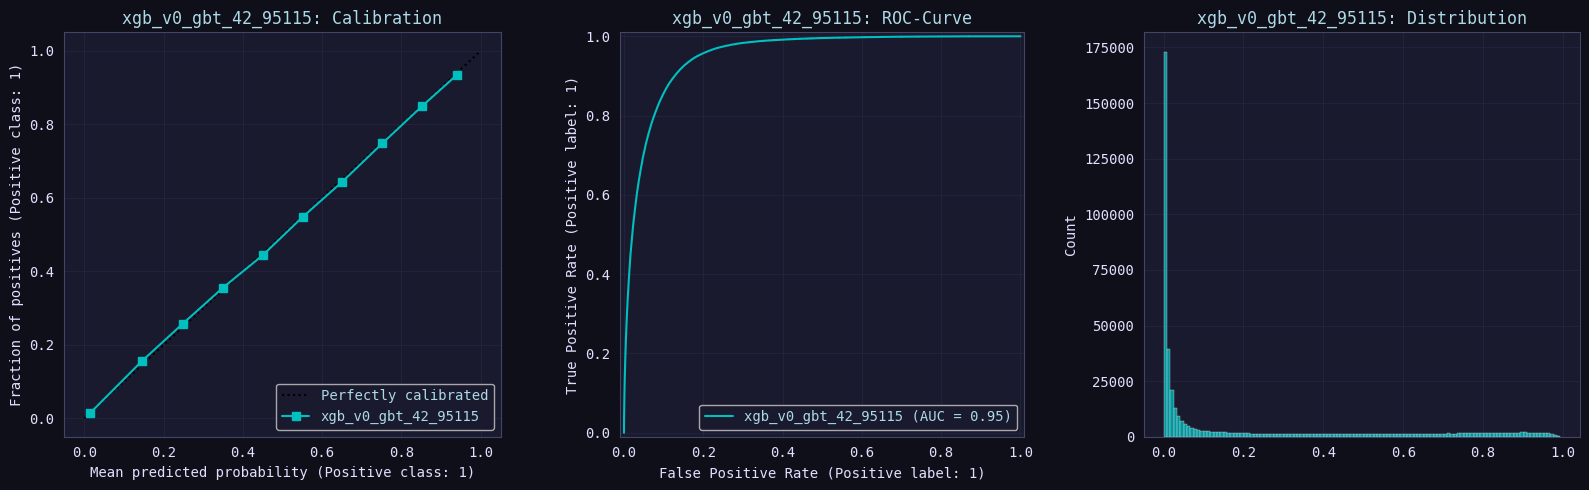


xgb_v0_gbt_777_95117 saved!


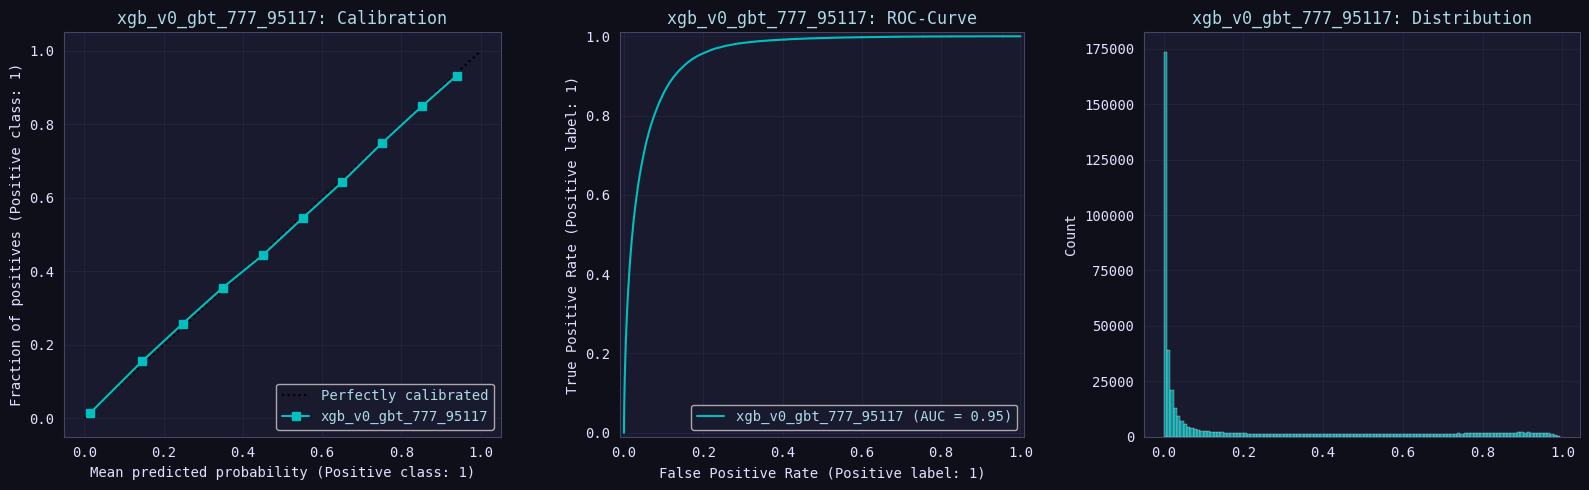


xgb_v0_gbt_1234_95116 saved!


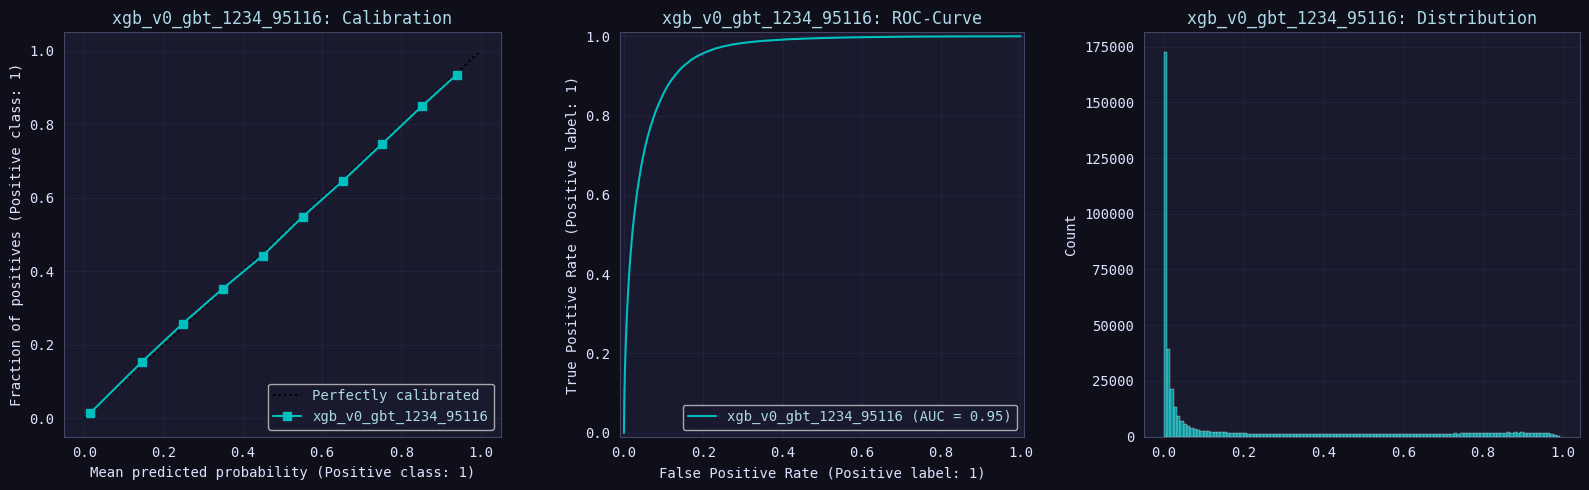


xgb_v0_gbt_24611_95117 saved!


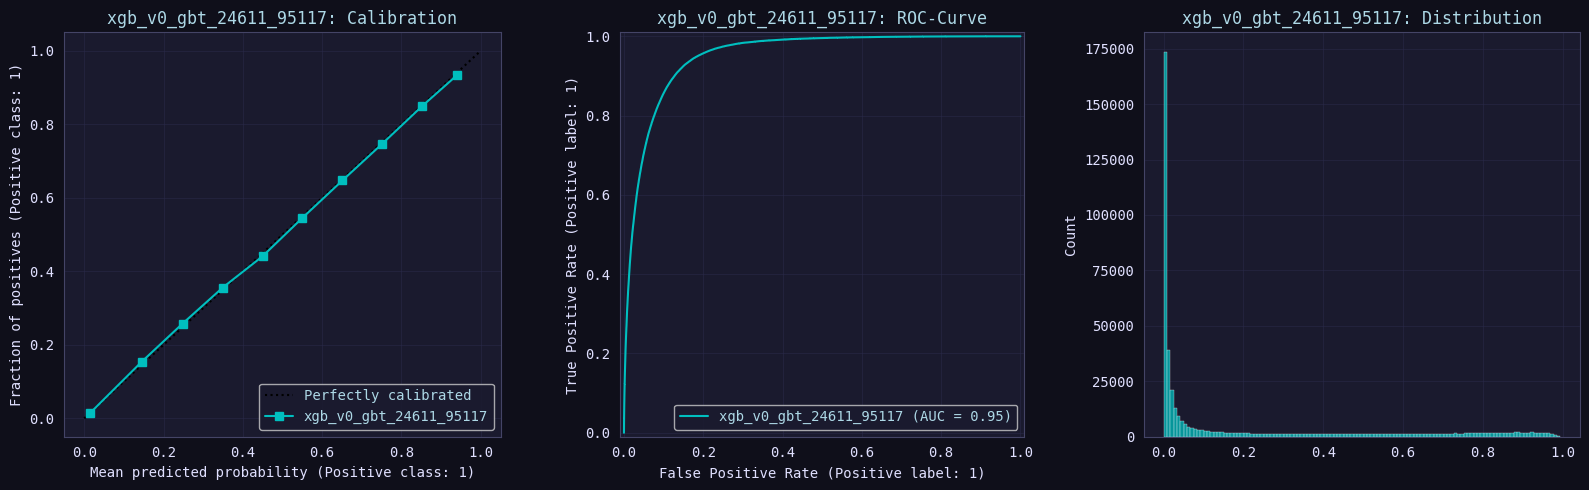


xgb_v0_gbt_0_95117 saved!


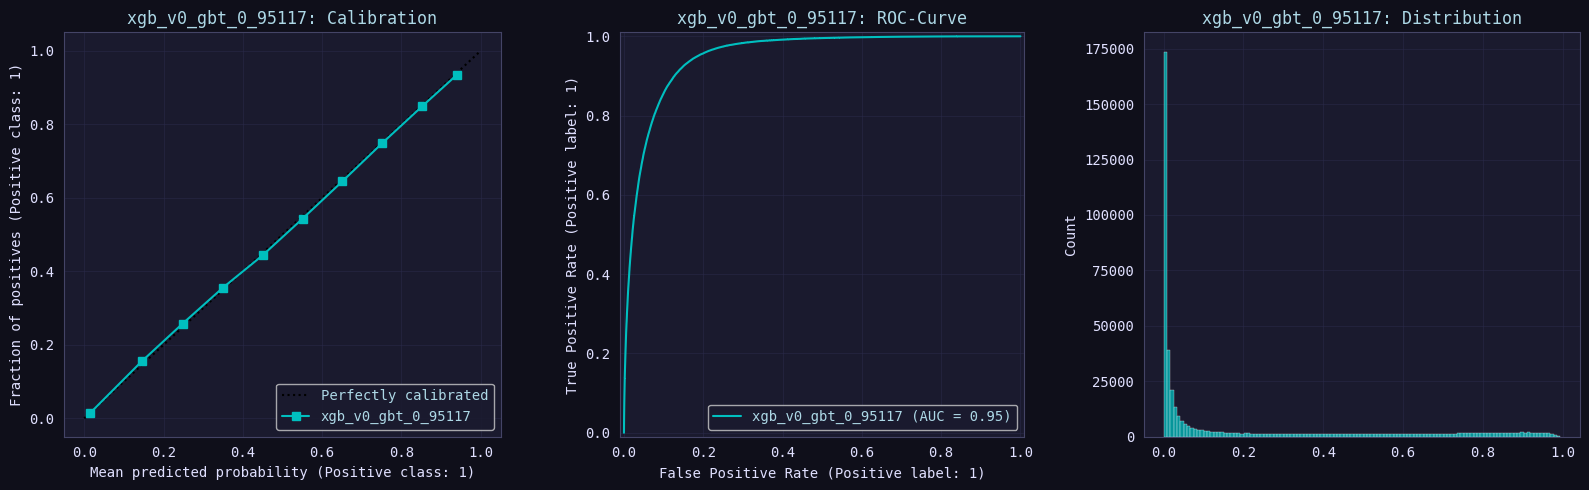


xgb_v0_loss_42_95129 saved!


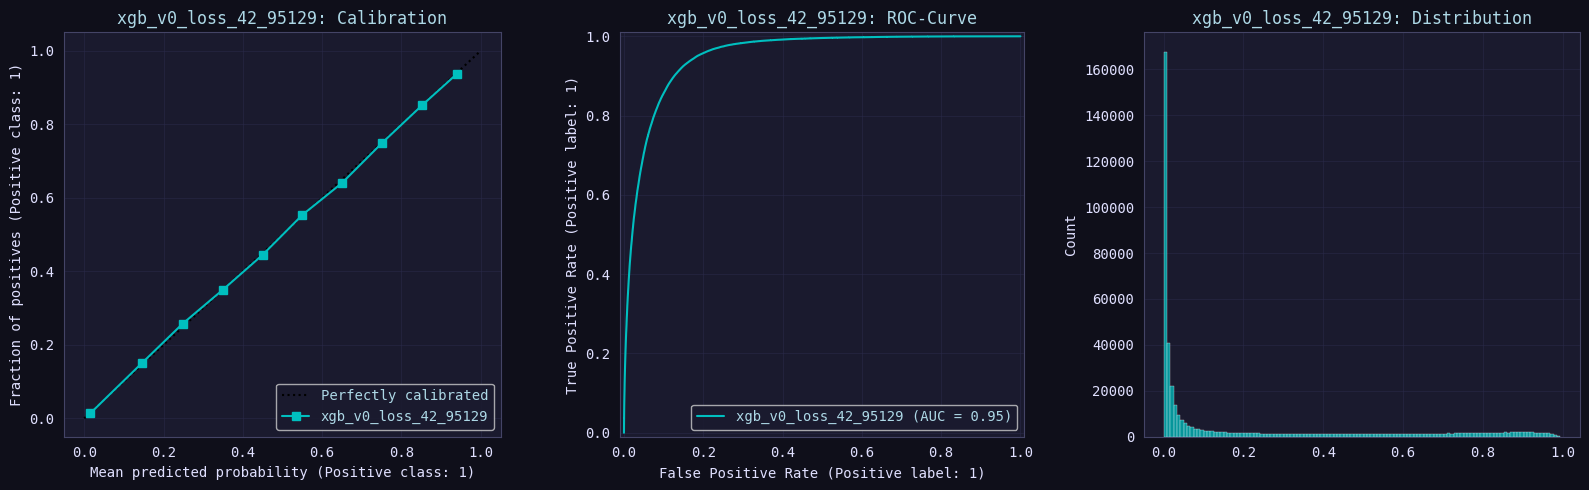


xgb_v0_loss_777_95129 saved!


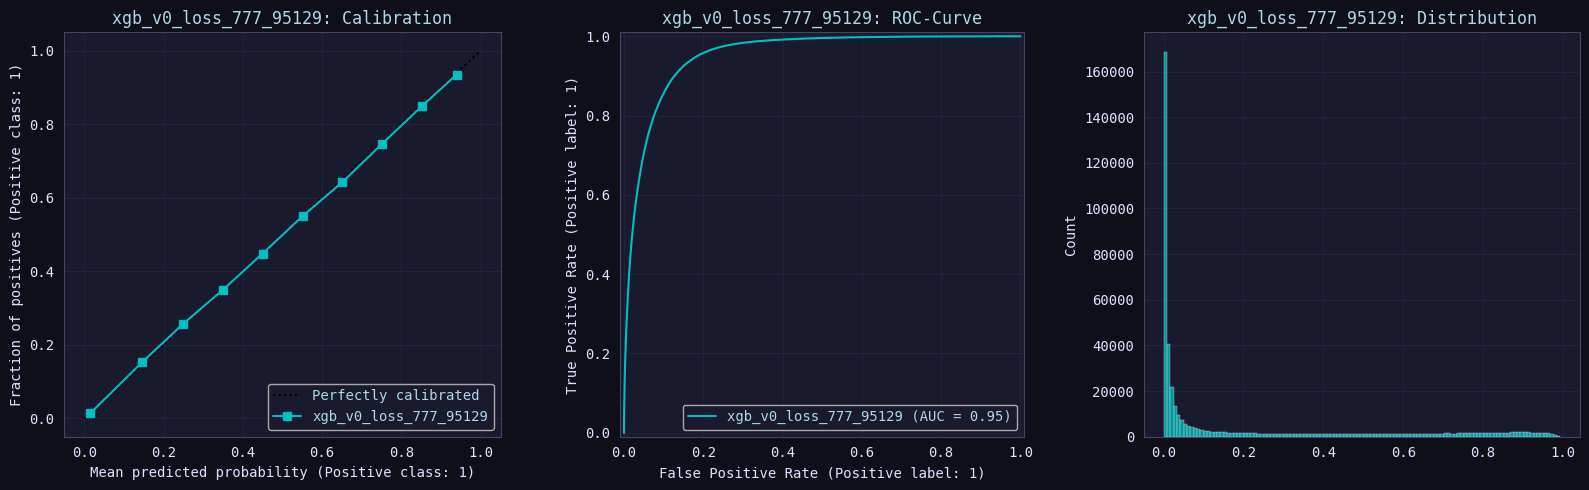


xgb_v0_loss_1234_95128 saved!


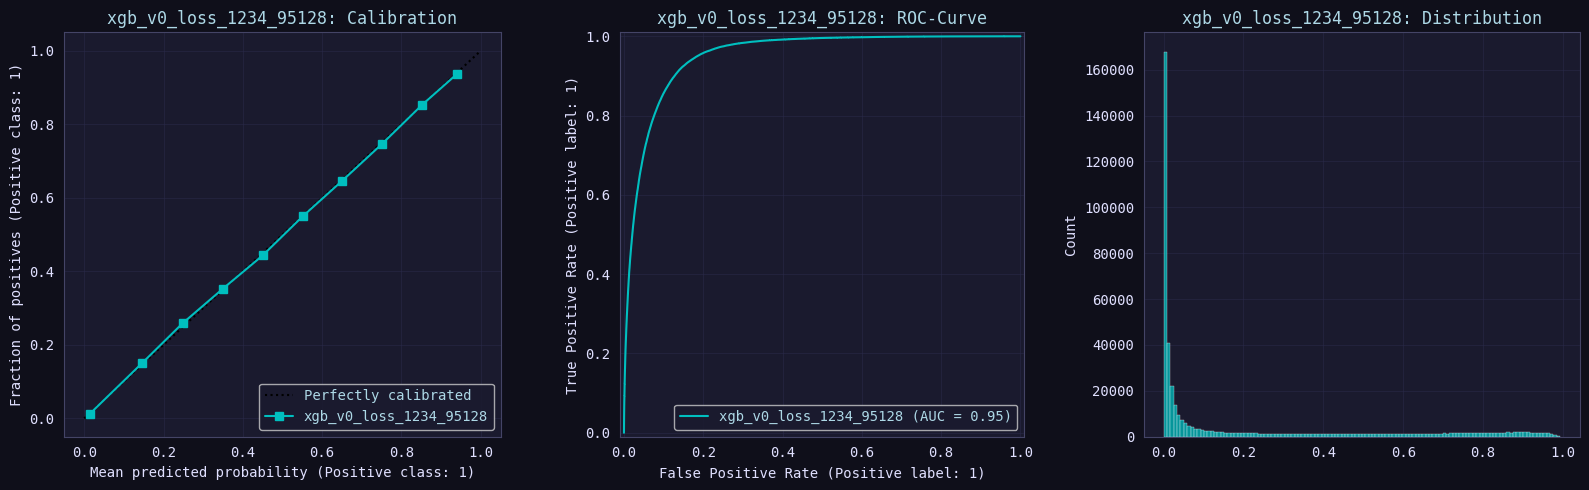


xgb_v0_loss_24611_95128 saved!


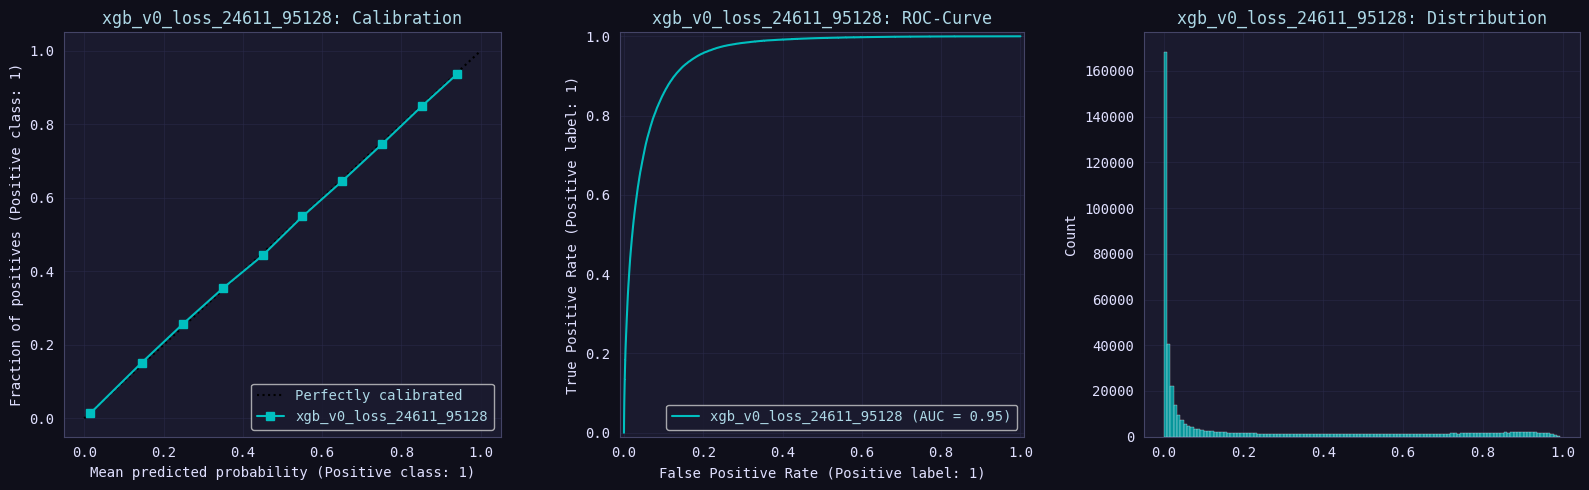


xgb_v0_loss_0_95127 saved!


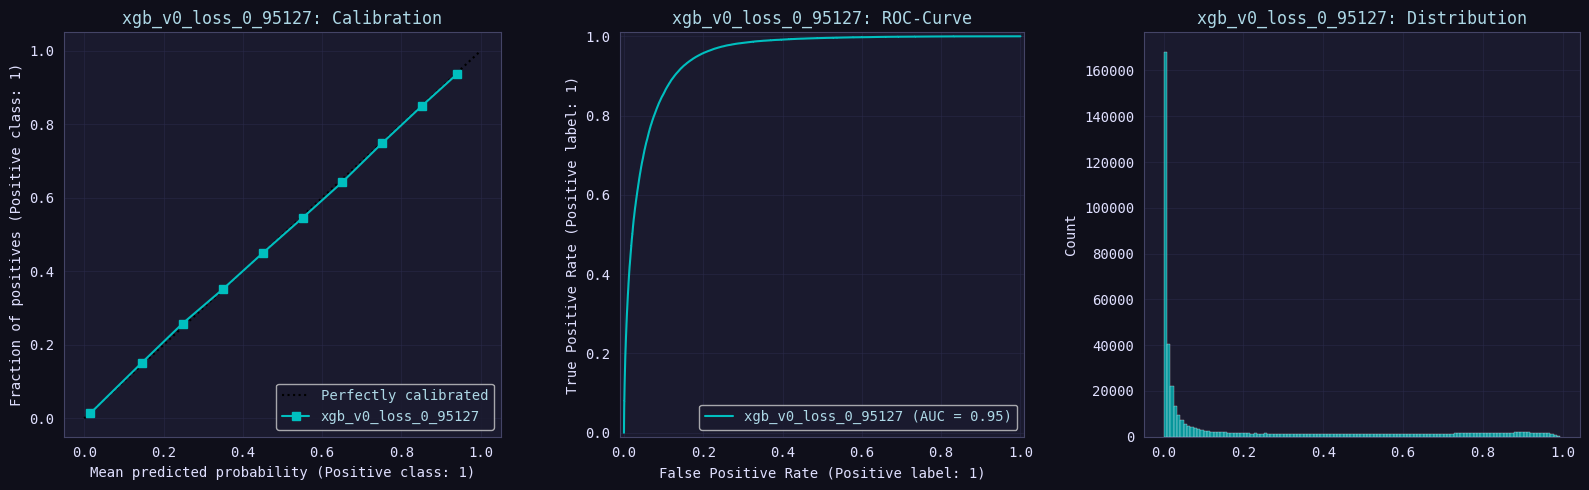


xgb_v0_grad_42_95083 saved!


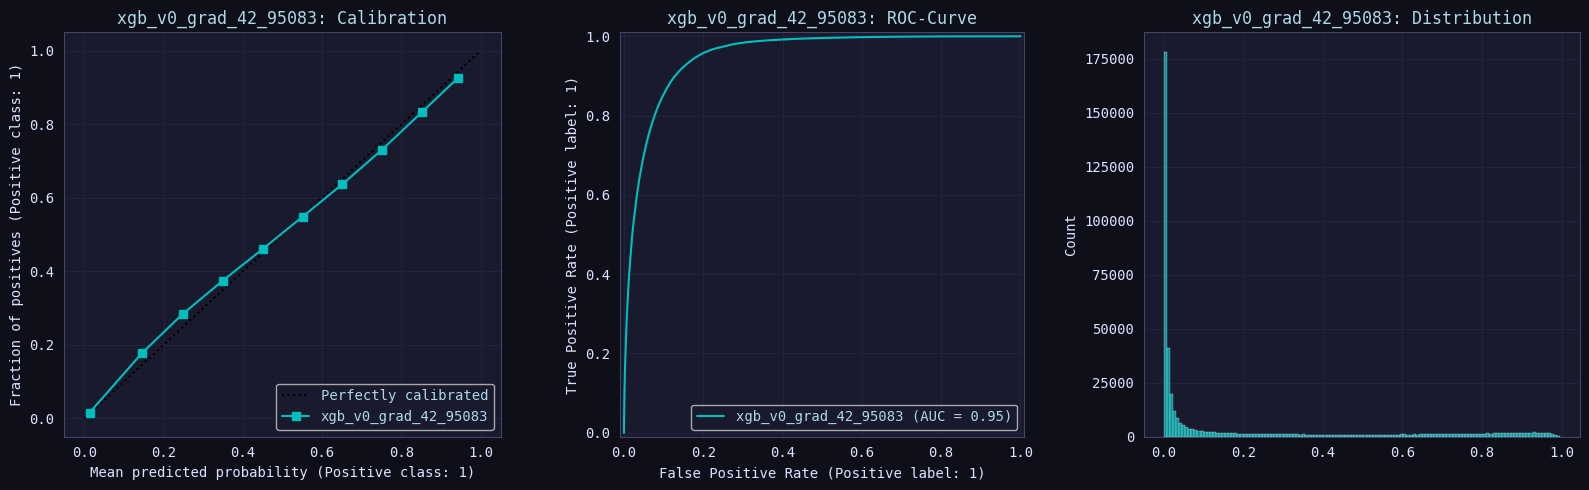


xgb_v0_grad_777_95085 saved!


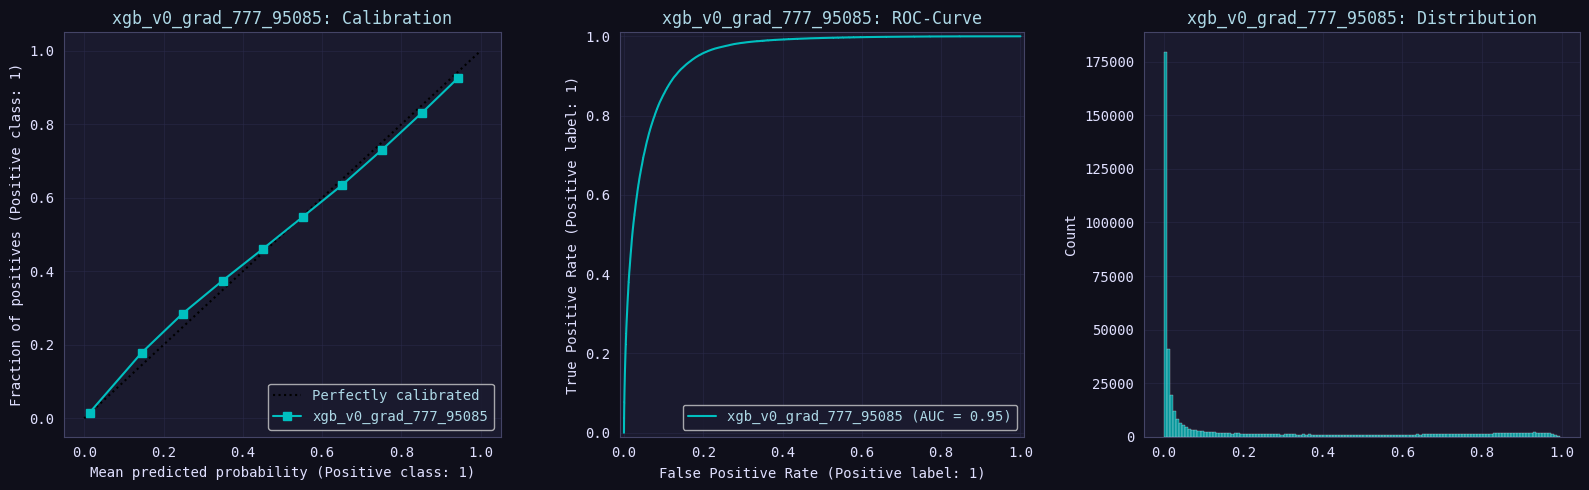


xgb_v0_grad_1234_95085 saved!


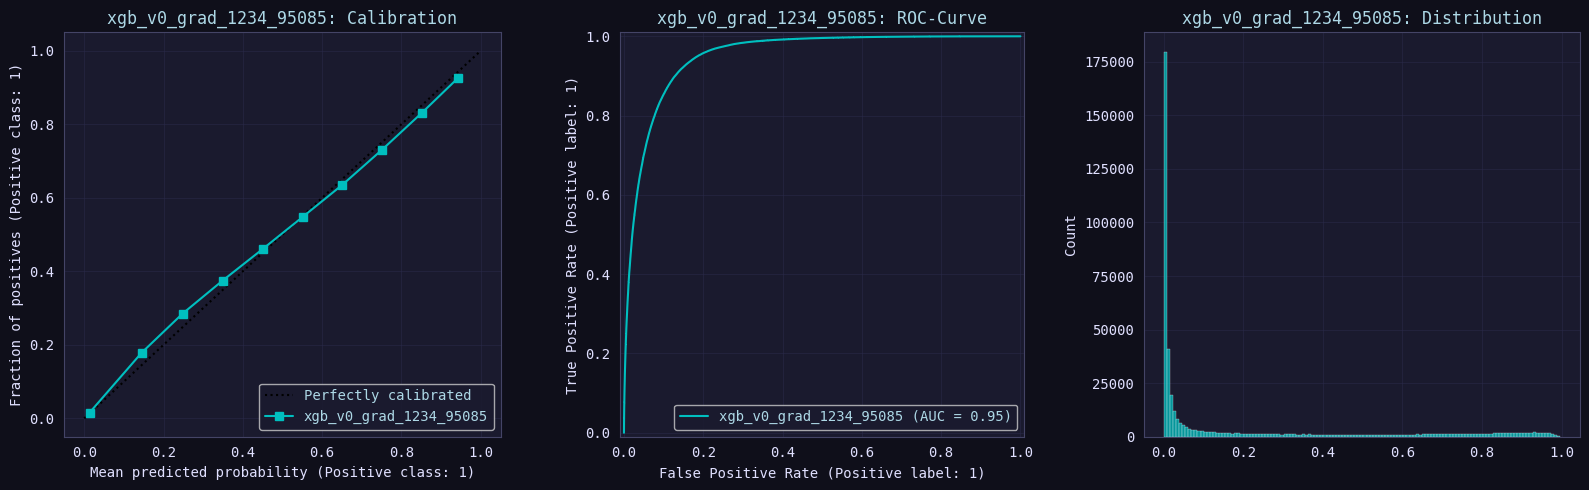


xgb_v0_grad_24611_95085 saved!


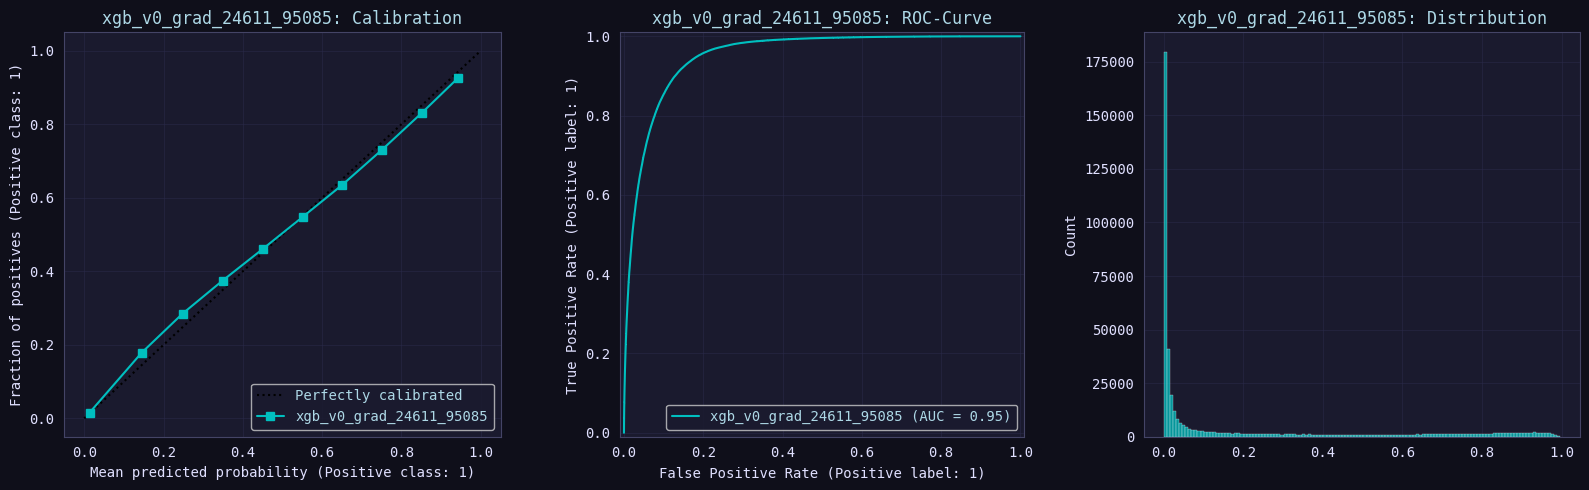


xgb_v0_grad_0_95085 saved!


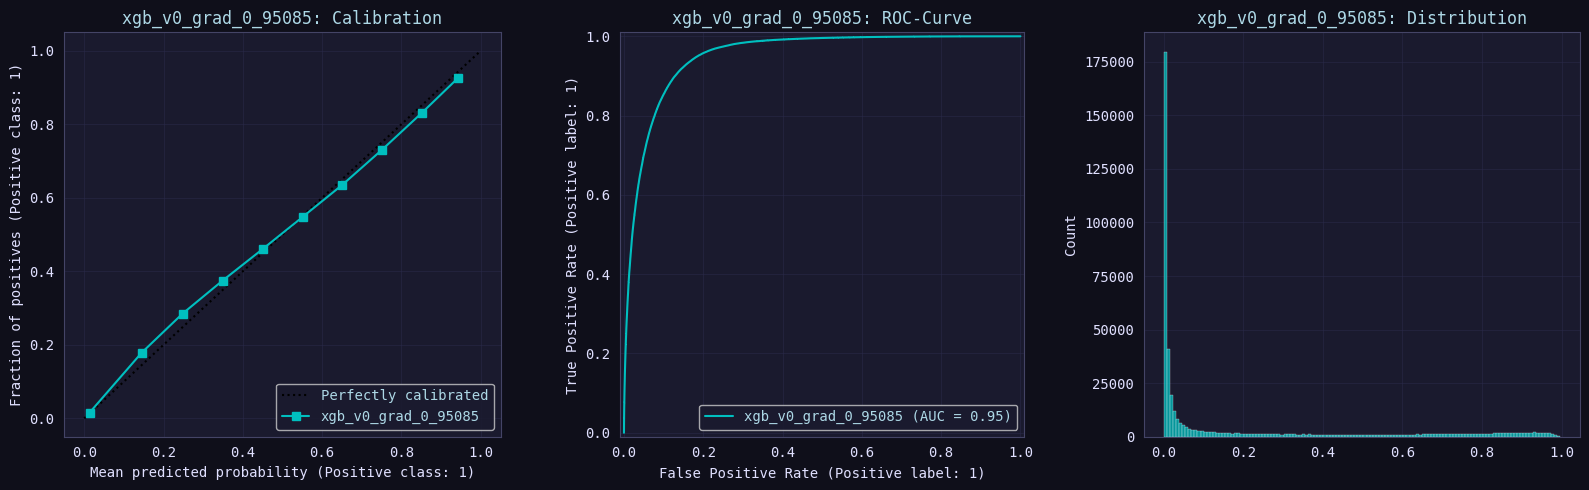

In [42]:
## -- Get oof predictions --

oof_predictions = []
for i, (k, v) in enumerate(all_model_predictions.items()):
    for key_, data_ in v.items():
        if key_ == 'oof_preds':
            ## -- Save oof predictions --
            n = f"{k}_{str(all_scores[i]).split('.')[1]}"
            np.save(f"oof_{n}.npy", data_)
            print(f'{n} saved!')

            ## -- Plot oof distributions --
            _, axs = plt.subplots(1, 3, figsize=(16, 5)) 
            CalibrationDisplay.from_predictions(train[TARGET], data_, n_bins=10, name=n, ax=axs[0])
            axs[0].set_title(f"{n}: Calibration")

            RocCurveDisplay.from_predictions(train[TARGET], data_, name=n, ax=axs[1])
            axs[1].set_title(f"{n}: ROC-Curve")

            sns.histplot(data_, ax=axs[2])
            axs[2].set_title(f"{n}: Distribution")
            
            plt.tight_layout()
            plt.show()

            print()

In [43]:
## -- Save test predictions/submissions --
for i, (k, v) in enumerate(all_model_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == 'test_preds':
            ## -- Base submission file --
            n = f"{k}_{str(all_scores[i]).split('.')[1]}"
            np.save(f"test_{n}.npy", y)

            submit[TARGET] = y
            submit.to_csv(f'submit_base_{n}.csv', index=False)
            print(f'{n} saved! {y.shape}')

submit.head(10)

xgb_v0_gbt_42_95115 saved! (188165,)
xgb_v0_gbt_777_95117 saved! (188165,)
xgb_v0_gbt_1234_95116 saved! (188165,)
xgb_v0_gbt_24611_95117 saved! (188165,)
xgb_v0_gbt_0_95117 saved! (188165,)
xgb_v0_loss_42_95129 saved! (188165,)
xgb_v0_loss_777_95129 saved! (188165,)
xgb_v0_loss_1234_95128 saved! (188165,)
xgb_v0_loss_24611_95128 saved! (188165,)
xgb_v0_loss_0_95127 saved! (188165,)
xgb_v0_grad_42_95083 saved! (188165,)
xgb_v0_grad_777_95085 saved! (188165,)
xgb_v0_grad_1234_95085 saved! (188165,)
xgb_v0_grad_24611_95085 saved! (188165,)
xgb_v0_grad_0_95085 saved! (188165,)


,id,PitNextLap
0,439140,0.006042
1,439141,0.006719
2,439142,0.002338
3,439143,0.192831
4,439144,0.848654
5,439145,0.071344
6,439146,0.000703
7,439147,0.008950
8,439148,0.016825
9,439149,0.001711


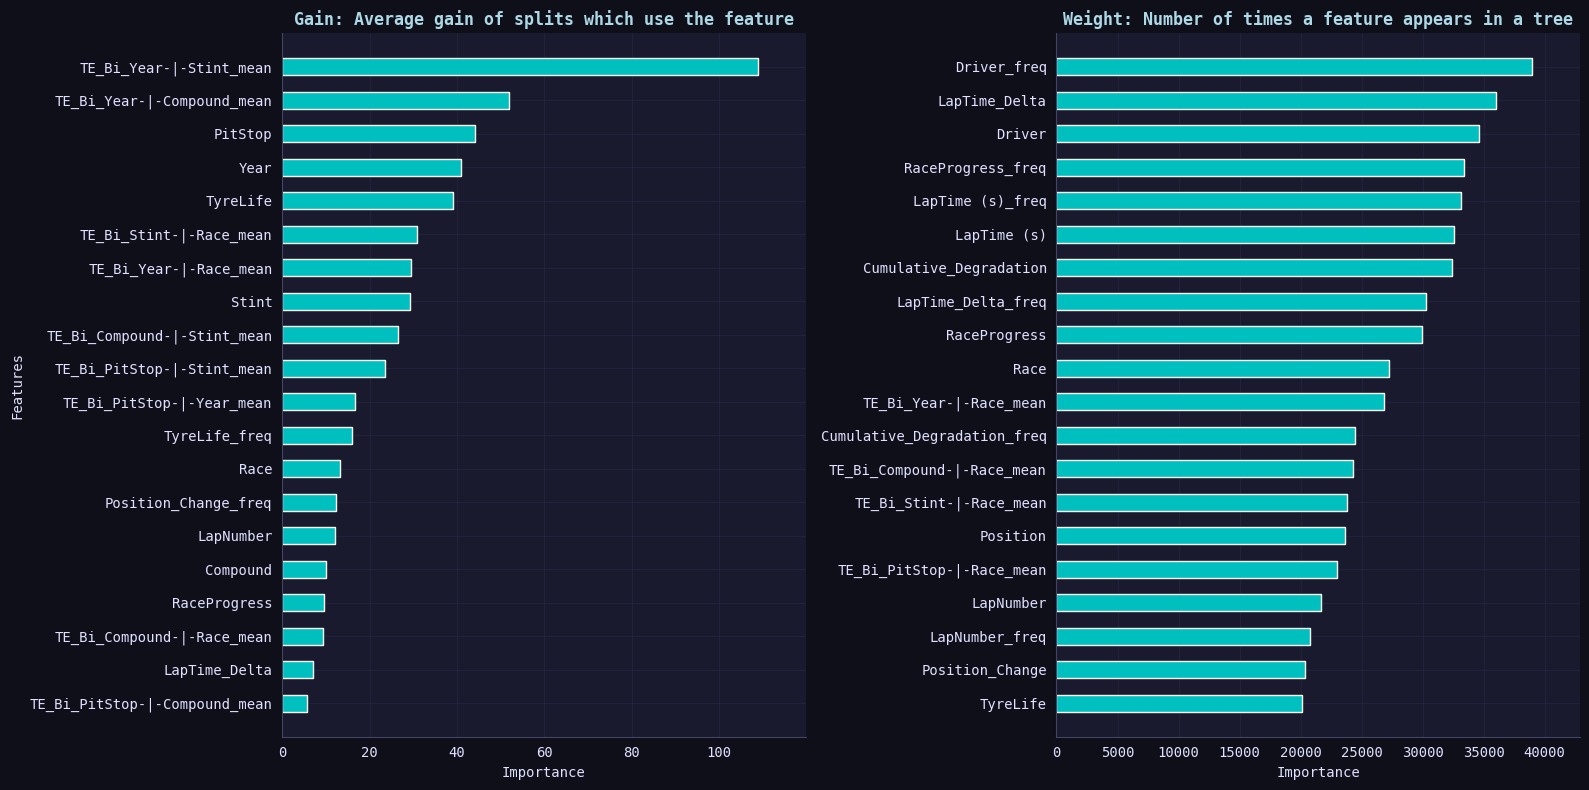

In [44]:
## -- Plot Feature Importances --
get_model = all_model_predictions[list(all_model_predictions.keys())[0]]

MAX = 20
_, axs = plt.subplots(1, 2, figsize=(16, 8))
xgb.plot_importance(
    get_model['model'],
    importance_type='gain',
    max_num_features=MAX,
    ax=axs[0], height=0.5,
    show_values=False,
)
axs[0].set_title('Gain: Average gain of splits which use the feature', fontweight='bold')

xgb.plot_importance(
    get_model['model'],
    importance_type='weight',
    max_num_features=MAX,
    ax=axs[1], height=0.5,
    show_values=False,
)
axs[1].set_title('Weight: Number of times a feature appears in a tree', fontweight='bold')
axs[1].set_ylabel('')

for ax in axs:
    ax.set_xlabel('Importance')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
plt.tight_layout()
plt.show()